# ID5059: Group Project

- The business outcome is to **reduce passenger waiting times** while **avoiding an excess of idle drivers**. You must present something *actionable* to the Operations Manager

- Your primary task is to build predictive models for **ride demand** for the Manhattan area. These
predictions should support recommendations **about driver deployment over time and space**.
You should also model **fare-related quantities** (such as average fare or total revenue per hour)
in order to explore which locations and times are likely to be most profitable for drivers.

- For example, you could predict a typical week, or a typical
week in each season (if you see a large fluctuation between summer and winter for example).

## Preamble

In [59]:
import pandas as pd 
import numpy as np
import datetime as dt
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import TimeSeriesSplit, cross_validate, GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

## Data cleaning/ Split

### Load in Raw Data

In [2]:
# Load in Raw data - Monthly data for 2024 (memory-efficient)
warnings.filterwarnings('ignore')

dtype_map = {
    'VendorID':              'Int8',
    'passenger_count':       'Int8',
    'trip_distance':         'float32',
    'RatecodeID':            'float32',
    'store_and_fwd_flag':    'str',
    'PULocationID':          'Int16',
    'DOLocationID':          'Int16',
    'payment_type':          'Int8',
    'fare_amount':           'float32',
    'extra':                 'float32',
    'mta_tax':               'float32',
    'tip_amount':            'float32',
    'tolls_amount':          'float32',
    'improvement_surcharge': 'float32',
    'total_amount':          'float32',
    'congestion_surcharge':  'float32',
    'Airport_fee':           'float32',
}

chunks = []
for m in range(1, 13):
    path = f'Raw Data/nyc_taxi_2024-{m:02d}.csv'
    df = pd.read_csv(path, dtype=dtype_map)
    chunks.append(df)
    print(f"Loaded {path}: {len(df):,} rows")
    del df  # free each monthly frame immediately

nyc_taxi_2024_Raw = pd.concat(chunks, ignore_index=True)
del chunks
print(f"\nTotal rows loaded: {len(nyc_taxi_2024_Raw):,}")

Loaded Raw Data/nyc_taxi_2024-01.csv: 2,964,624 rows
Loaded Raw Data/nyc_taxi_2024-02.csv: 3,007,526 rows
Loaded Raw Data/nyc_taxi_2024-03.csv: 3,582,628 rows
Loaded Raw Data/nyc_taxi_2024-04.csv: 3,514,289 rows
Loaded Raw Data/nyc_taxi_2024-05.csv: 3,723,833 rows
Loaded Raw Data/nyc_taxi_2024-06.csv: 3,539,193 rows
Loaded Raw Data/nyc_taxi_2024-07.csv: 3,076,903 rows
Loaded Raw Data/nyc_taxi_2024-08.csv: 2,979,183 rows
Loaded Raw Data/nyc_taxi_2024-09.csv: 3,633,030 rows
Loaded Raw Data/nyc_taxi_2024-10.csv: 3,833,771 rows
Loaded Raw Data/nyc_taxi_2024-11.csv: 3,646,369 rows
Loaded Raw Data/nyc_taxi_2024-12.csv: 3,668,371 rows

Total rows loaded: 41,169,720


In [3]:
nyc_taxi_2024 = nyc_taxi_2024_Raw.copy()

### Data cleaning/Aggregation and Features

In [4]:
# Load TLC zone lookup to identify Manhattan zones reproducibly.
zones = pd.read_csv('Raw Data/taxi_zone_lookup.csv')

manhattan_zones = set(zones.loc[zones['Borough'] == 'Manhattan', 'LocationID'])
print(f"Manhattan zones loaded: {len(manhattan_zones)} zones")

# Parse datetimes (stored as strings in raw CSVs)
nyc_taxi_2024['tpep_pickup_datetime']  = pd.to_datetime(nyc_taxi_2024['tpep_pickup_datetime'])
nyc_taxi_2024['tpep_dropoff_datetime'] = pd.to_datetime(nyc_taxi_2024['tpep_dropoff_datetime'])

# Fix mixed-type store_and_fwd_flag (Y/N strings with NaN in some months)
nyc_taxi_2024['store_and_fwd_flag'] = (
    nyc_taxi_2024['store_and_fwd_flag']
    .astype(str).str.upper()
    .map({'Y': True, 'N': False})
)

# congestion_surcharge and Airport_fee are absent for some vendor records, not truly missing
nyc_taxi_2024['congestion_surcharge'] = nyc_taxi_2024['congestion_surcharge'].fillna(0)
nyc_taxi_2024['Airport_fee']          = nyc_taxi_2024['Airport_fee'].fillna(0)

# Naively Drop invalid and voided records.
# Note: payment_type=0 rows are always the same rows as null passenger_count and
# null RatecodeID (Vendor 2 records with missing metadata), so the payment_type
# filter is sufficient to remove all of them, but each condition is kept explicit.
# RatecodeID=99 is a separate invalid code (not in the TLC data dictionary) and
# is filtered independently.
n0 = len(nyc_taxi_2024)

valid = (
    (nyc_taxi_2024['fare_amount']    >  0)  &  # negative = void/correction
    (nyc_taxi_2024['total_amount']   >  0)  &
    (nyc_taxi_2024['trip_distance']  >  0)  &  # zero-distance ghost trips
    (nyc_taxi_2024['passenger_count'] > 0)  &  # NaN rows also excluded by > 0
    (nyc_taxi_2024['payment_type']   != 0)  &  # 0 = vendor metadata missing
    (~nyc_taxi_2024['RatecodeID'].isin([99, np.nan])) &  # 99 = invalid/unknown rate
    (nyc_taxi_2024['tpep_dropoff_datetime'] > nyc_taxi_2024['tpep_pickup_datetime'])
)
nyc_taxi_2024 = nyc_taxi_2024[valid]

# Compute trip duration, then drop implausible trips
nyc_taxi_2024['trip_duration_min'] = (
    (nyc_taxi_2024['tpep_dropoff_datetime'] - nyc_taxi_2024['tpep_pickup_datetime'])
    .dt.total_seconds() / 60
)

nyc_taxi_2024 = nyc_taxi_2024[
    (nyc_taxi_2024['trip_distance']    <= 100) &  # >100 miles implausible in NYC
    (nyc_taxi_2024['fare_amount']      <= 100) &  # extreme fare outliers
    (nyc_taxi_2024['trip_duration_min'].between(1, 300))  # <1 min or >5 hrs
]

print(f"Dropped {n0 - len(nyc_taxi_2024):,} invalid/outlier rows "
        f"({(n0 - len(nyc_taxi_2024)) / n0:.1%} of total)")

# Filter to Manhattan pickups only
n1 = len(nyc_taxi_2024)
nyc_taxi_2024 = nyc_taxi_2024[nyc_taxi_2024['PULocationID'].isin(manhattan_zones)]
print(f"Dropped {n1 - len(nyc_taxi_2024):,} non-Manhattan rows "
        f"({(n1 - len(nyc_taxi_2024)) / n1:.1%} of post-cleaning total)")

# Temporal features at trip level
nyc_taxi_2024['pickup_hour']  = nyc_taxi_2024['tpep_pickup_datetime'].dt.hour
nyc_taxi_2024['pickup_dow']   = nyc_taxi_2024['tpep_pickup_datetime'].dt.dayofweek  # 0=Mon
nyc_taxi_2024['pickup_month'] = nyc_taxi_2024['tpep_pickup_datetime'].dt.month
nyc_taxi_2024['pickup_date']  = nyc_taxi_2024['tpep_pickup_datetime'].dt.normalize()
nyc_taxi_2024['season']       = nyc_taxi_2024['pickup_month'].map(
    {12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
)
nyc_taxi_2024['is_weekend']   = nyc_taxi_2024['pickup_dow'].isin([5, 6])
nyc_taxi_2024['is_rush_hour'] = nyc_taxi_2024['pickup_hour'].isin([7, 8, 9, 16, 17, 18, 19])

# Aggregate to hourly zone-level demand table.
# trip_count and total_revenue are the two model targets.
# avg_fare and avg_duration are kept as descriptive summaries for EDA only.
# Trip-level stats unknowable at forecast time (e.g. fare_per_mile, tip_rate)
# are excluded as they cannot be used as inputs when predicting future demand.
nyc_taxi_2024_aggregated = (
    nyc_taxi_2024
    .groupby(['PULocationID', 'pickup_date', 'pickup_hour'])
    .agg(
        trip_count       = ('VendorID',         'count'),  # TARGET: demand
        total_revenue    = ('total_amount',      'sum'),   # TARGET: revenue
        avg_fare         = ('fare_amount',       'mean'),  # EDA only
        avg_duration_min = ('trip_duration_min', 'mean'),  # EDA only
    )
    .reset_index()
)

# Re-attach time features (all deterministic from date + hour, so no groupby ambiguity)
nyc_taxi_2024_aggregated['pickup_dow']   = nyc_taxi_2024_aggregated['pickup_date'].dt.dayofweek
nyc_taxi_2024_aggregated['pickup_month'] = nyc_taxi_2024_aggregated['pickup_date'].dt.month
nyc_taxi_2024_aggregated['season']       = nyc_taxi_2024_aggregated['pickup_month'].map(
    {12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
)
nyc_taxi_2024_aggregated['is_weekend']   = nyc_taxi_2024_aggregated['pickup_dow'].isin([5, 6])
nyc_taxi_2024_aggregated['is_rush_hour'] = nyc_taxi_2024_aggregated['pickup_hour'].isin([7, 8, 9, 16, 17, 18, 19])

nyc_taxi_2024_aggregated = nyc_taxi_2024_aggregated.sort_values(['PULocationID', 'pickup_date', 'pickup_hour']).reset_index(drop=True)

# Lag and rolling features for both targets.
# A pivot (hour × zone) is reindexed to a gapless hourly DatetimeIndex before
# shifting, so each shift() step is an exact time interval regardless of missing
# zone-hours in the aggregation. Zero-trip hours are filled with 0 in the pivot
# but no extra rows are added to demand. Only the original aggregated rows are kept.
nyc_taxi_2024_aggregated['pickup_datetime'] = (
    nyc_taxi_2024_aggregated['pickup_date'] + pd.to_timedelta(nyc_taxi_2024_aggregated['pickup_hour'], unit='h')
)


Manhattan zones loaded: 69 zones
Dropped 6,234,406 invalid/outlier rows (15.1% of total)
Dropped 3,533,865 non-Manhattan rows (10.1% of post-cleaning total)


### Train/Test Split

In [5]:
# Split dataset into train/test sets
# First 3 weeks (days 1-21) of each month - train
# Last week (days 22+) of each month - test

taxi_clean_train = nyc_taxi_2024_aggregated[nyc_taxi_2024_aggregated['pickup_date'].dt.day <= 21].copy()
taxi_clean_test  = nyc_taxi_2024_aggregated[nyc_taxi_2024_aggregated['pickup_date'].dt.day  > 21].copy()

### Feature Engineering

In [6]:
# Feature engineering

def feature_engineering(taxidata):

    full_dt_idx = pd.date_range(
        start=taxidata['pickup_datetime'].min(),
        end=taxidata['pickup_datetime'].max(),
        freq='h'
    )
    lookup_idx = pd.MultiIndex.from_arrays(
        [taxidata['pickup_datetime'], taxidata['PULocationID']]
    )

    for target, prefix in [('trip_count', 'demand'), ('total_revenue', 'revenue')]:
        pivot = (
            taxidata.pivot_table(
                index='pickup_datetime', columns='PULocationID',
                values=target, aggfunc='sum'
            )
            .reindex(full_dt_idx, fill_value=0)
        )
        taxidata[f'{prefix}_lag_1h']   = pivot.shift(1).stack().reindex(lookup_idx).values
        taxidata[f'{prefix}_lag_24h']  = pivot.shift(24).stack().reindex(lookup_idx).values
        taxidata[f'{prefix}_lag_1w']   = pivot.shift(168).stack().reindex(lookup_idx).values
        taxidata[f'{prefix}_roll_24h'] = (
            pivot.shift(1).rolling(24, min_periods=12).mean()
            .stack().reindex(lookup_idx).values
        )
        
    # Cyclical encoding of hour
    taxidata['hour_sin'] = np.sin(2 * np.pi * taxidata['pickup_hour'] / 24)
    taxidata['hour_cos'] = np.cos(2 * np.pi * taxidata['pickup_hour'] / 24)

    # Hour x weekend interaction
    taxidata['hour_x_weekend'] = taxidata['pickup_hour'] * taxidata['is_weekend'].astype(int)


    taxidata = taxidata.drop(columns='pickup_datetime')
    # drop rows with any missing lag features (e.g. first 24h of data, or zones with sparse demand)
    # only about 2% of rows
    taxidata = taxidata.dropna(subset= [col for col in taxidata.columns if 'lag' in col])

    # Convert to Data Wrangler-compatible types (DW cannot serialise datetime64 or bool)
    taxidata['pickup_date']  = taxidata['pickup_date'].astype(str)
    taxidata['is_weekend']   = taxidata['is_weekend'].astype(int)
    taxidata['is_rush_hour'] = taxidata['is_rush_hour'].astype(int)

    print(f"\nFinal demand table: {taxidata.shape[0]:,} rows x {taxidata.shape[1]} columns")
    print(f"Targets: trip_count (demand), total_revenue (revenue)")

    taxidata_cleaned = taxidata.copy()

    return taxidata_cleaned


In [7]:
# Add features into the training set

taxi_clean = feature_engineering(taxi_clean_train)


Final demand table: 311,348 rows x 23 columns
Targets: trip_count (demand), total_revenue (revenue)


In [32]:
# Add features to both training and test set
taxi_clean_train = feature_engineering(taxi_clean_train)
taxi_clean_test  = feature_engineering(taxi_clean_test)


Final demand table: 311,348 rows x 23 columns
Targets: trip_count (demand), total_revenue (revenue)

Final demand table: 141,010 rows x 23 columns
Targets: trip_count (demand), total_revenue (revenue)


### Data Dictionary : Cleaned Demand Table (`taxi_clean`)

Each row represents **one pickup zone × one hour** combination.  
Only Manhattan pickup zones are included (69 TLC zones).

---

### Identifiers / Time Index

| Column | Type | Description |
|---|---|---|
| `PULocationID` | int | TLC taxi zone ID for the pickup location. Maps to the `taxi_zone_lookup.csv` reference table. |
| `pickup_date` | str (YYYY-MM-DD) | Calendar date of the pickup hour. |
| `pickup_hour` | int (0–23) | Hour of day (24-hour clock) for the pickup window. |

---

### Target Variables

| Column | Type | Description |
|---|---|---|
| `trip_count` | int | **Primary target.** Total number of trips that started in this zone during this hour. Measures ride demand. |
| `total_revenue` | float | **Secondary target.** Sum of `total_amount` (USD) across all trips in this zone-hour. Measures revenue potential. |

---

### Descriptive Summaries *(EDA only! do not use as model features)*

| Column | Type | Description |
|---|---|---|
| `avg_fare` | float | Mean base fare (`fare_amount`) in USD for trips in this zone-hour. Excludes surcharges and tips. |
| `avg_duration_min` | float | Mean trip duration in minutes for trips in this zone-hour. |

---

### Temporal Features

| Column | Type | Description |
|---|---|---|
| `pickup_dow` | int (0–6) | Day of the week: 0 = Monday, 6 = Sunday. |
| `pickup_month` | int (1–12) | Calendar month of the pickup. |
| `season` | str | Season derived from month: `Winter` (Dec–Feb), `Spring` (Mar–May), `Summer` (Jun–Aug), `Autumn` (Sep–Nov). |
| `is_weekend` | int (0/1) | 1 if the pickup falls on Saturday or Sunday, 0 otherwise. |
| `is_rush_hour` | int (0/1) | 1 if the pickup hour is in the AM rush (07:00–09:00) or PM rush (16:00–19:00), 0 otherwise. |

---

### Lag & Rolling Features: Demand (`trip_count`)

| Column | Type | Description |
|---|---|---|
| `demand_lag_1h` | float | `trip_count` for the **same zone, 1 hour earlier**. Captures short-term momentum. |
| `demand_lag_24h` | float | `trip_count` for the **same zone, 24 hours earlier**. Captures same-hour-yesterday demand. |
| `demand_lag_1w` | float | `trip_count` for the **same zone, 168 hours (1 week) earlier**. Captures weekly seasonality. |
| `demand_roll_24h` | float | Rolling 24-hour **mean** of `trip_count` for the same zone, computed over the 24 hours *before* the current hour (no data leakage). |

---

### Lag & Rolling Features: Revenue (`total_revenue`)

| Column | Type | Description |
|---|---|---|
| `revenue_lag_1h` | float | `total_revenue` for the **same zone, 1 hour earlier**. |
| `revenue_lag_24h` | float | `total_revenue` for the **same zone, 24 hours earlier**. |
| `revenue_lag_1w` | float | `total_revenue` for the **same zone, 168 hours (1 week) earlier**. |
| `revenue_roll_24h` | float | Rolling 24-hour **mean** of `total_revenue` for the same zone, computed over the 24 hours before the current hour. |

---

> **Note on NaN values:** Lag and rolling columns will be `NaN` for the first hours of the dataset (insufficient history). These rows should be dropped or imputed before model training.


## General Exploratory Data Analysis

Understanding the data better.

In [8]:
taxi_clean.shape

(311348, 23)

In [9]:
taxi_clean.columns

Index(['PULocationID', 'pickup_date', 'pickup_hour', 'trip_count',
       'total_revenue', 'avg_fare', 'avg_duration_min', 'pickup_dow',
       'pickup_month', 'season', 'is_weekend', 'is_rush_hour', 'demand_lag_1h',
       'demand_lag_24h', 'demand_lag_1w', 'demand_roll_24h', 'revenue_lag_1h',
       'revenue_lag_24h', 'revenue_lag_1w', 'revenue_roll_24h', 'hour_sin',
       'hour_cos', 'hour_x_weekend'],
      dtype='str')

In [10]:
taxi_clean.dtypes

PULocationID          Int16
pickup_date             str
pickup_hour           int32
trip_count            Int64
total_revenue       float32
avg_fare            float32
avg_duration_min    float64
pickup_dow            int32
pickup_month          int32
season                  str
is_weekend            int64
is_rush_hour          int64
demand_lag_1h         Int64
demand_lag_24h        Int64
demand_lag_1w         Int64
demand_roll_24h     float64
revenue_lag_1h      float32
revenue_lag_24h     float32
revenue_lag_1w      float32
revenue_roll_24h    float64
hour_sin            float64
hour_cos            float64
hour_x_weekend        int64
dtype: object

In [11]:
# pickup_date should be datetime so converting from str to datetime
taxi_clean['pickup_date'] = pd.to_datetime(taxi_clean['pickup_date'])

In [12]:
# checking time continuity for pickup date
taxi_clean['pickup_date'].min(), taxi_clean['pickup_date'].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2025-03-02 00:00:00'))

In [13]:
# check zone imbalance
taxi_clean['PULocationID'].value_counts().head()

PULocationID
48     6047
186    6047
68     6045
100    6044
79     6043
Name: count, dtype: Int64

In [14]:
# checking missing values
taxi_clean.isna().sum()

PULocationID          0
pickup_date           0
pickup_hour           0
trip_count            0
total_revenue         0
avg_fare              0
avg_duration_min      0
pickup_dow            0
pickup_month          0
season                0
is_weekend            0
is_rush_hour          0
demand_lag_1h         0
demand_lag_24h        0
demand_lag_1w         0
demand_roll_24h     821
revenue_lag_1h        0
revenue_lag_24h       0
revenue_lag_1w        0
revenue_roll_24h    821
hour_sin              0
hour_cos              0
hour_x_weekend        0
dtype: int64

In [15]:
lag_roll_cols = [col for col in taxi_clean.columns if ('lag' in col) or ('roll' in col)]
taxi_clean = taxi_clean.dropna(subset=lag_roll_cols)

In [16]:
taxi_clean.isna().sum()

PULocationID        0
pickup_date         0
pickup_hour         0
trip_count          0
total_revenue       0
avg_fare            0
avg_duration_min    0
pickup_dow          0
pickup_month        0
season              0
is_weekend          0
is_rush_hour        0
demand_lag_1h       0
demand_lag_24h      0
demand_lag_1w       0
demand_roll_24h     0
revenue_lag_1h      0
revenue_lag_24h     0
revenue_lag_1w      0
revenue_roll_24h    0
hour_sin            0
hour_cos            0
hour_x_weekend      0
dtype: int64

In [17]:
taxi_clean.describe()

,PULocationID,pickup_date,pickup_hour,trip_count,total_revenue,avg_fare,avg_duration_min,pickup_dow,pickup_month,is_weekend,...,demand_lag_24h,demand_lag_1w,demand_roll_24h,revenue_lag_1h,revenue_lag_24h,revenue_lag_1w,revenue_roll_24h,hour_sin,hour_cos,hour_x_weekend
count,310527.0,310527,310527.000000,310527.0,310527.000000,310527.000000,310527.000000,310527.000000,310527.000000,310527.000000,...,310527.0,310527.0,310527.000000,310527.000000,310527.000000,310527.000000,310527.000000,310527.000000,3.105270e+05,310527.000000
mean,151.905515,2024-06-26 21:07:50.463437,12.176332,70.847221,1676.150391,16.711088,13.830339,3.052330,6.519514,0.295701,...,67.369977,46.904559,67.561989,1672.640991,1594.246216,1108.165161,1598.808749,-0.066364,-4.964238e-02,3.517691
min,4.0,2024-01-01 00:00:00,0.000000,1.0,1.010000,0.010000,1.000000,0.000000,1.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000e+00,0.000000
25%,90.0,2024-04-01 00:00:00,7.000000,11.0,273.705002,13.366666,10.927944,1.000000,4.000000,0.000000,...,8.0,0.0,21.737986,269.649994,211.349998,0.000000,546.114739,-0.707107,-7.071068e-01,0.000000
50%,151.0,2024-07-01 00:00:00,12.000000,40.0,961.440002,15.283333,13.151282,3.000000,7.000000,0.000000,...,36.0,11.0,56.304348,957.320007,863.510010,269.399994,1300.313332,0.000000,-1.836970e-16,0.000000
75%,230.0,2024-10-01 00:00:00,18.000000,103.0,2354.609985,18.250000,16.018205,5.000000,10.000000,1.000000,...,98.0,66.0,99.125000,2351.585083,2255.880005,1524.214966,2281.065418,0.707107,7.071068e-01,3.000000
max,263.0,2025-03-02 00:00:00,23.000000,996.0,21620.949219,100.000000,263.266667,6.000000,12.000000,1.000000,...,996.0,996.0,359.375000,21620.949219,21620.949219,21620.949219,8412.274158,1.000000,1.000000e+00,23.000000
std,72.364265,NaN,6.759003,83.140927,1975.409424,6.163425,4.568134,2.001476,3.441726,0.456358,...,82.601747,75.308661,56.594725,1975.848877,1962.397949,1785.871826,1343.580164,0.697793,7.114913e-01,6.594459


In [18]:
# check non unique values
taxi_clean.nunique()

PULocationID            63
pickup_date            254
pickup_hour             24
trip_count             658
total_revenue       208028
avg_fare            142257
avg_duration_min    225721
pickup_dow               7
pickup_month            12
season                   4
is_weekend               2
is_rush_hour             2
demand_lag_1h          659
demand_lag_24h         658
demand_lag_1w          640
demand_roll_24h      17309
revenue_lag_1h      207650
revenue_lag_24h     200361
revenue_lag_1w      152438
revenue_roll_24h    309788
hour_sin                21
hour_cos                22
hour_x_weekend          24
dtype: int64

In [19]:
# check duplicates
taxi_clean.duplicated().sum()

np.int64(0)

In [20]:
# checking feature scales
taxi_clean.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
PULocationID,151.905515,72.364265,4.0,263.0
pickup_date,2024-06-26 21:07:50.463437,NaN,2024-01-01 00:00:00,2025-03-02 00:00:00
pickup_hour,12.176332,6.759003,0.0,23.0
trip_count,70.847221,83.140927,1.0,996.0
total_revenue,1676.150391,1975.409424,1.01,21620.949219
avg_fare,16.711088,6.163425,0.01,100.0
avg_duration_min,13.830339,4.568134,1.0,263.266667
pickup_dow,3.05233,2.001476,0.0,6.0
pickup_month,6.519514,3.441726,1.0,12.0
is_weekend,0.295701,0.456358,0.0,1.0


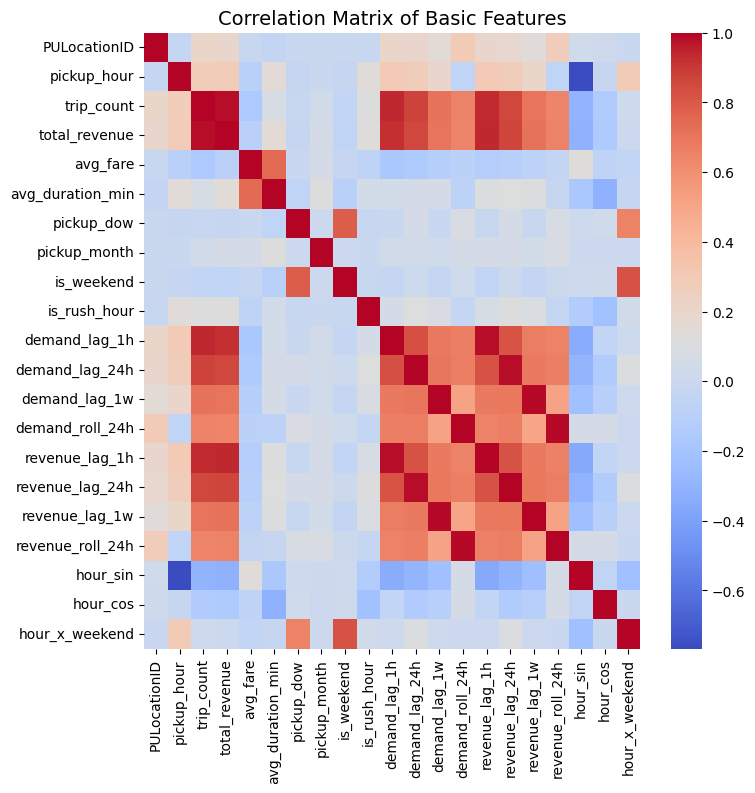

In [21]:
# checking correlation between features
corr = taxi_clean.corr(numeric_only=True)

plt.figure(figsize=(8, 8))
sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Matrix of Basic Features", fontsize=14)
plt.show()

## Exploratory Data Analysis : Predicting Demand

Understanding the data better.

In [22]:
# general function to use for the chosen target variable, plotting relationships between target and other features

def eda_target(df, target_variable):
    print(f"\nEDA for target variable: {target_variable}\n")

    # plotting distribution of the target variable
    plt.figure(figsize=(6, 4))
    plt.hist(df[target_variable], bins=50)
    plt.title(f"Distribution of {target_variable}")
    plt.xlabel(target_variable)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # plotting target variable against numeric features
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col != target_variable]

    if numeric_cols:
        n_cols = 3
        n_rows = math.ceil(len(numeric_cols) / n_cols)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

        for i, col in enumerate(numeric_cols):
            ax = axes[i]
            sns.scatterplot(
                x=df[col],
                y=df[target_variable],
                alpha=0.1,
                s=10,
                ax=ax
            )
            ax.set_title(f"{target_variable} vs {col}")
            ax.set_xlabel(col)
            ax.set_ylabel(target_variable)

        for j in range(len(numeric_cols), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    # plotting target variable against categorical features
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    extra_cat_cols = ['PULocationID', 'pickup_hour', 'pickup_dow', 'pickup_month', 'season']
    cat_cols += [col for col in extra_cat_cols if col in df.columns]

    cat_cols = list(set(cat_cols))
    cat_cols = [col for col in cat_cols if col != target_variable]

    if cat_cols:
        n_cols = 3
        n_rows = math.ceil(len(cat_cols) / n_cols)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

        day_map = {
            0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu',
            4: 'Fri', 5: 'Sat', 6: 'Sun'
        }

        month_map = {
            1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
            5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
            9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
        }

        for i, col in enumerate(cat_cols):
            ax = axes[i]
            mean_vals = df.groupby(col)[target_variable].mean()

            if col == 'pickup_dow':
                mean_vals.index = mean_vals.index.map(day_map)
                mean_vals = mean_vals.reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
                mean_vals.plot(kind='bar', ax=ax)

            elif col == 'pickup_month':
                mean_vals.index = mean_vals.index.map(month_map)
                mean_vals = mean_vals.reindex(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
                mean_vals.plot(kind='bar', ax=ax)

            elif col == 'pickup_hour':
                mean_vals = mean_vals.sort_index()
                mean_vals.plot(kind='line', ax=ax)

            else:
                if mean_vals.shape[0] > 15:
                    mean_vals = mean_vals.sort_values(ascending=False).head(15)
                mean_vals.plot(kind='bar', ax=ax)

            ax.set_title(f"{target_variable} by {col}")
            ax.set_xlabel(col)
            ax.set_ylabel(f"Average {target_variable}")
            ax.tick_params(axis='x', rotation=45)

        for j in range(len(cat_cols), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()


EDA for target variable: trip_count



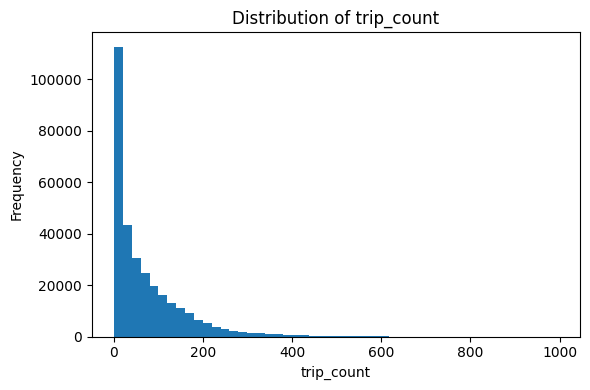

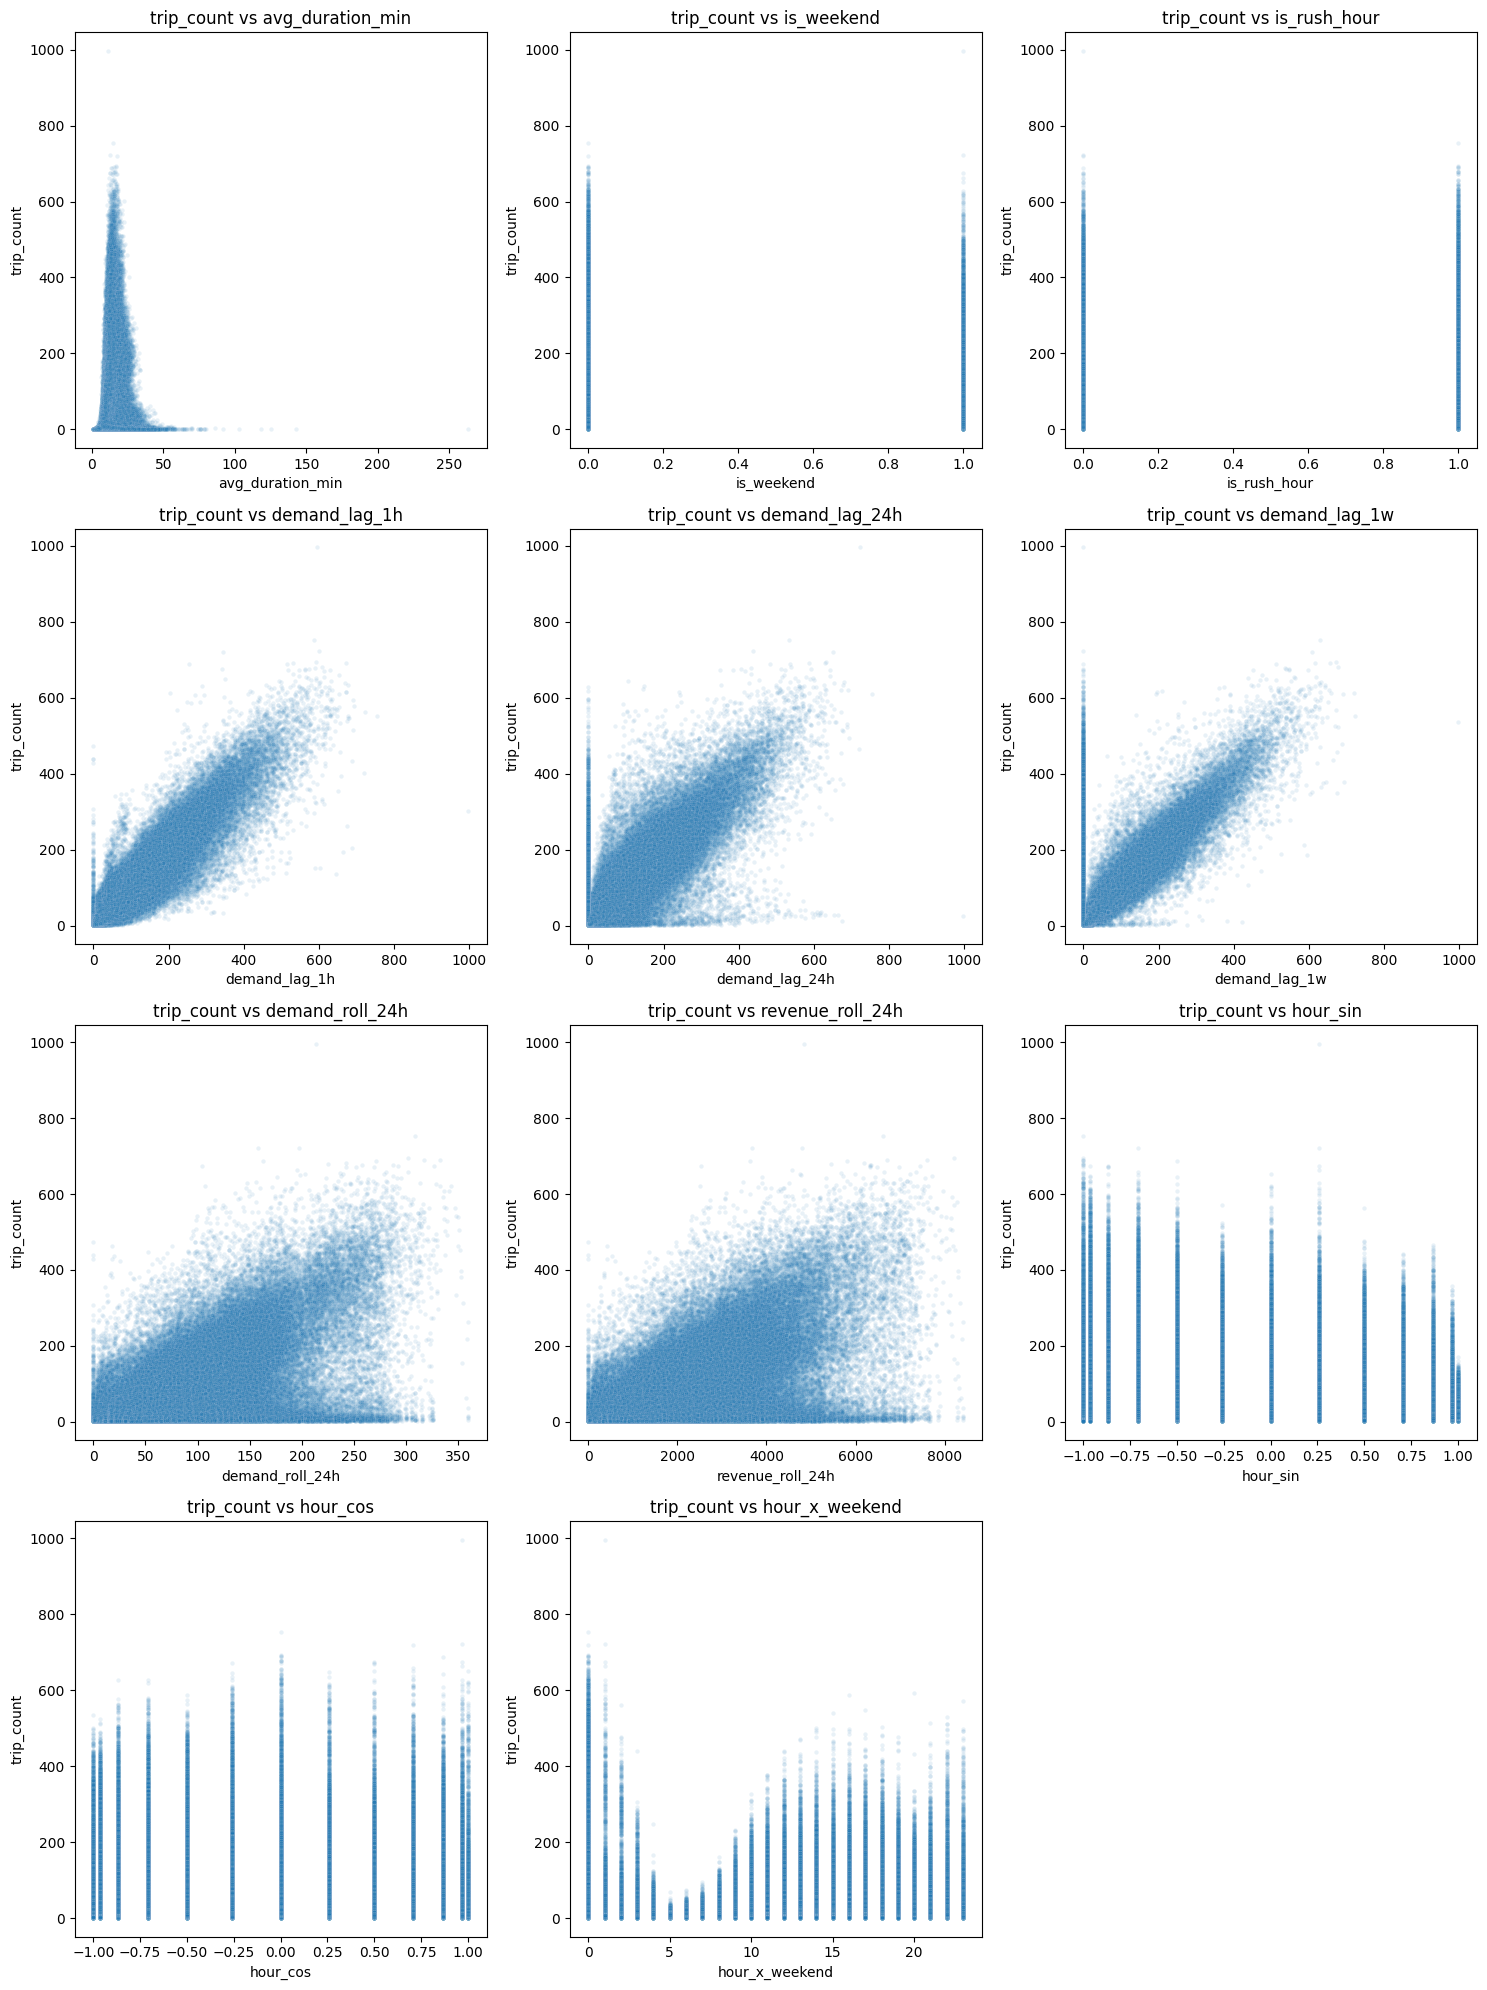

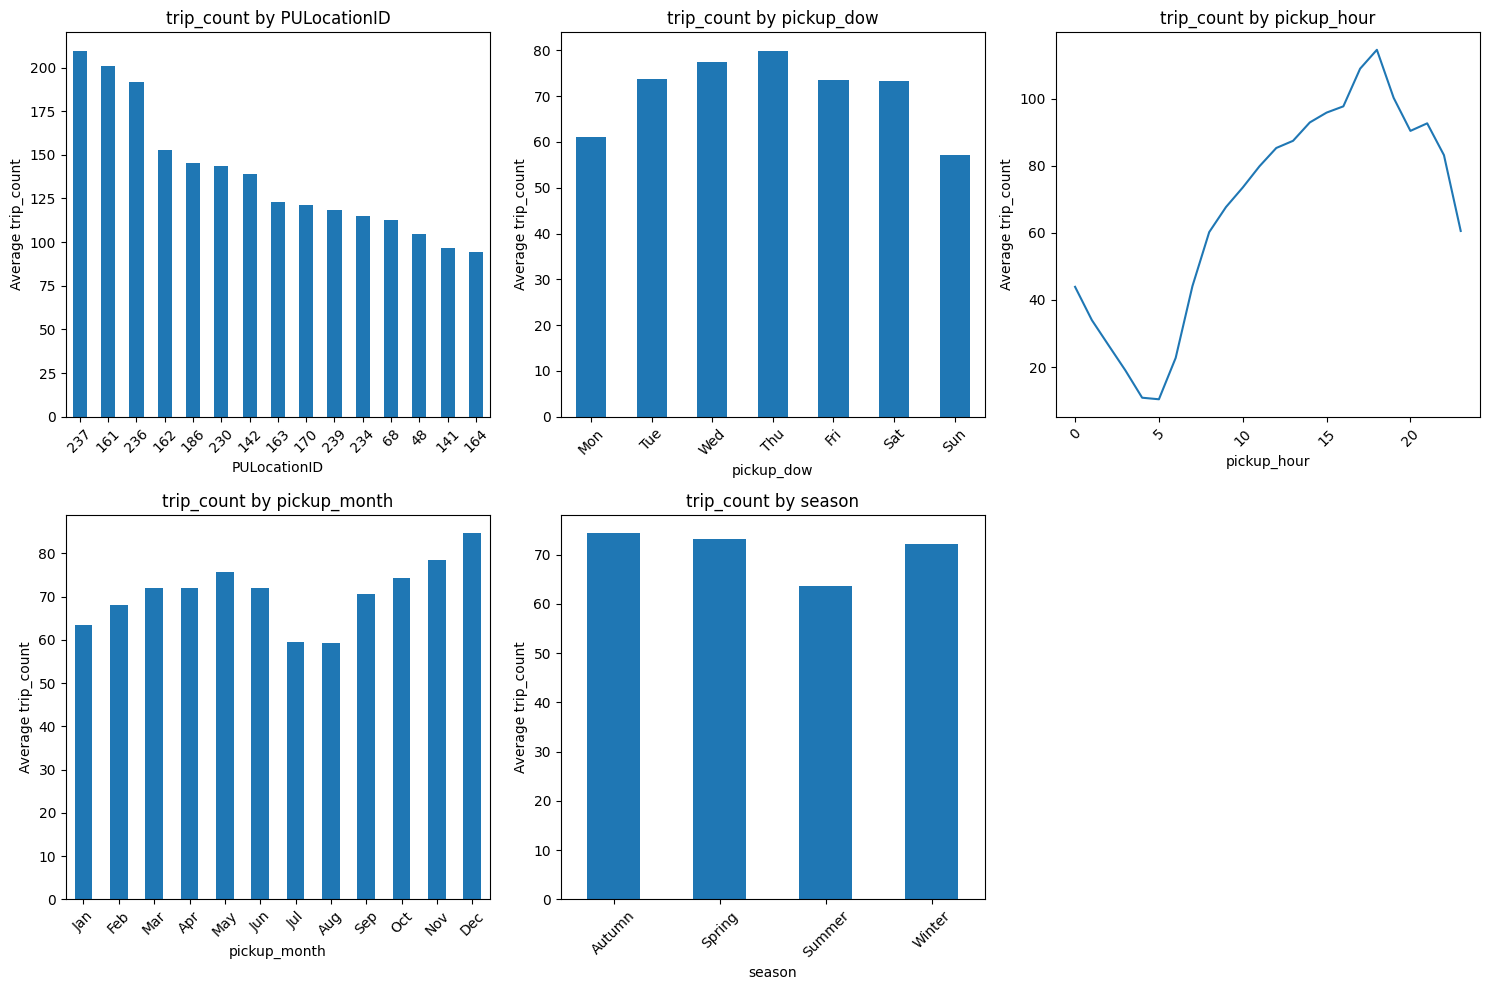

In [23]:
eda_target(taxi_clean, 'trip_count')

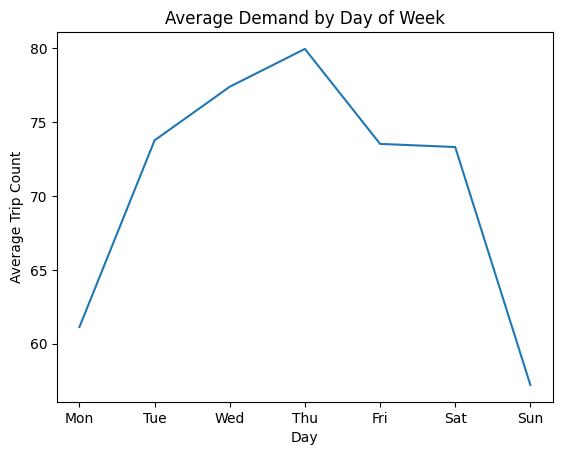

In [24]:
# plotting demand by day of week

# creating days of the week map for visualization
day_map = {
    0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu',
    4: 'Fri', 5: 'Sat', 6: 'Sun'
}

demand_by_day = taxi_clean.groupby('pickup_dow')['trip_count'].mean()

demand_by_day.index = demand_by_day.index.map(day_map)

demand_by_day.plot()

plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Trip Count")

plt.show()

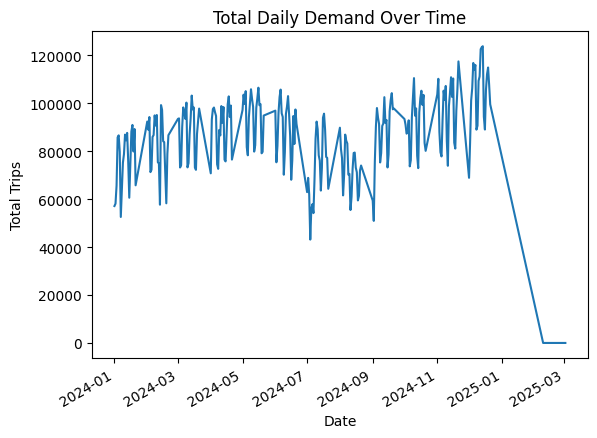

In [25]:
# plotting demand over time to check stability and trends

taxi_clean.groupby('pickup_date')['trip_count'].sum().plot()
plt.title("Total Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Trips")
plt.show()

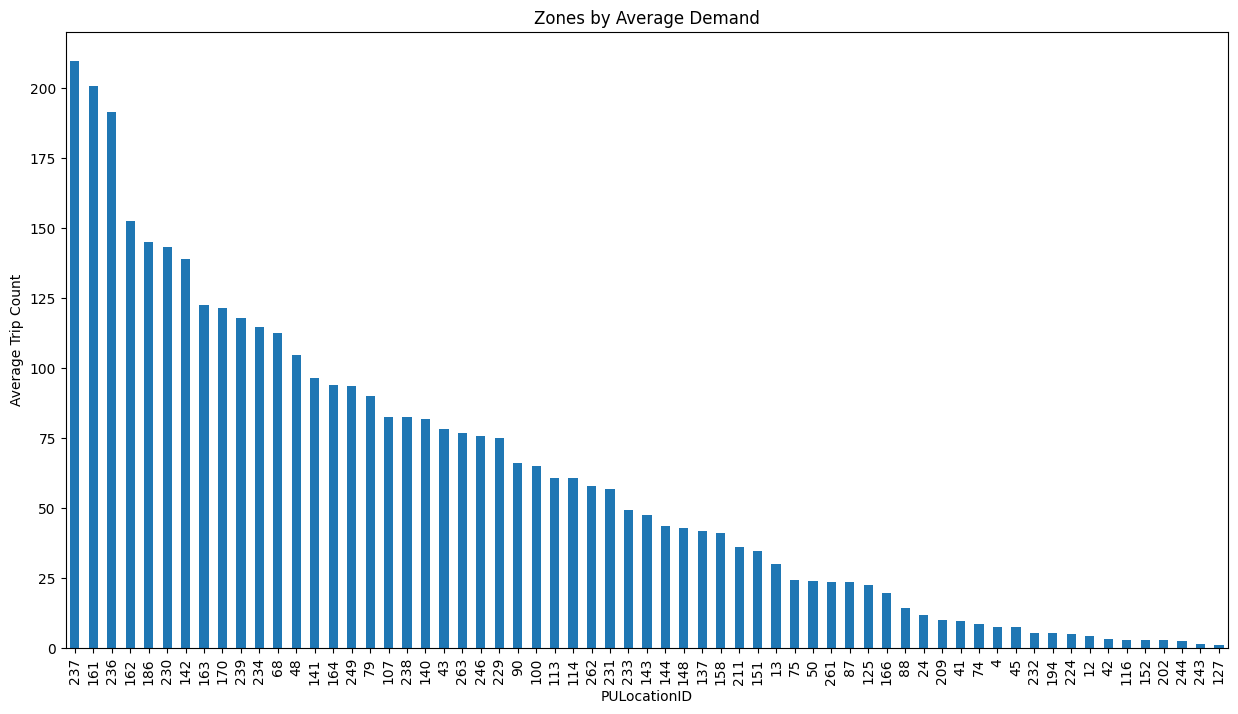

In [26]:
# plotting zone level demand differences

top_zones = taxi_clean.groupby('PULocationID')['trip_count'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 8))
top_zones.plot(kind='bar')
plt.title("Zones by Average Demand")
plt.ylabel("Average Trip Count")
plt.show()

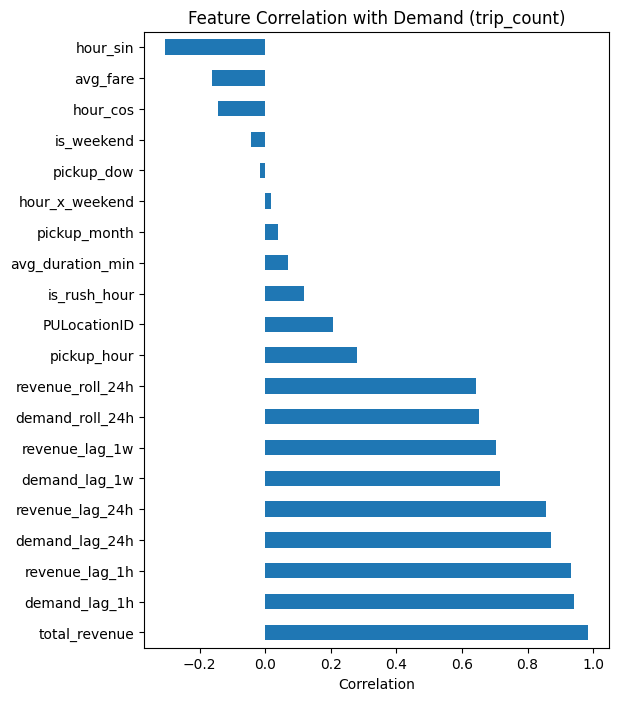

In [27]:
# checking correlation with target variable

corr = taxi_clean.corr(numeric_only=True)['trip_count'].sort_values(ascending=False)

plt.figure(figsize=(6,8))
corr.drop('trip_count').plot(kind='barh')
plt.title("Feature Correlation with Demand (trip_count)")
plt.xlabel("Correlation")
plt.show()

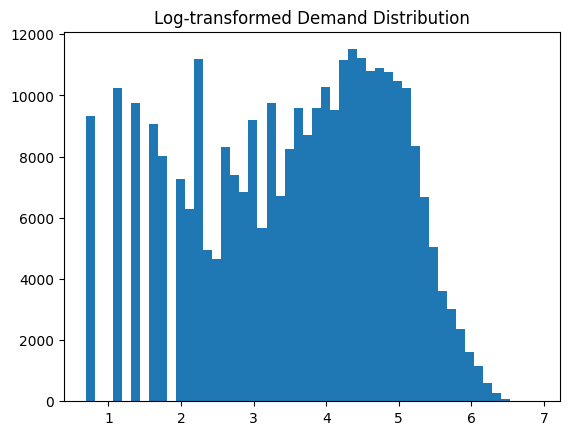

In [28]:
# checking if log transform is needed for demand based on the log distribution

plt.hist(np.log1p(taxi_clean['trip_count']), bins=50)
plt.title("Log-transformed Demand Distribution")
plt.show()

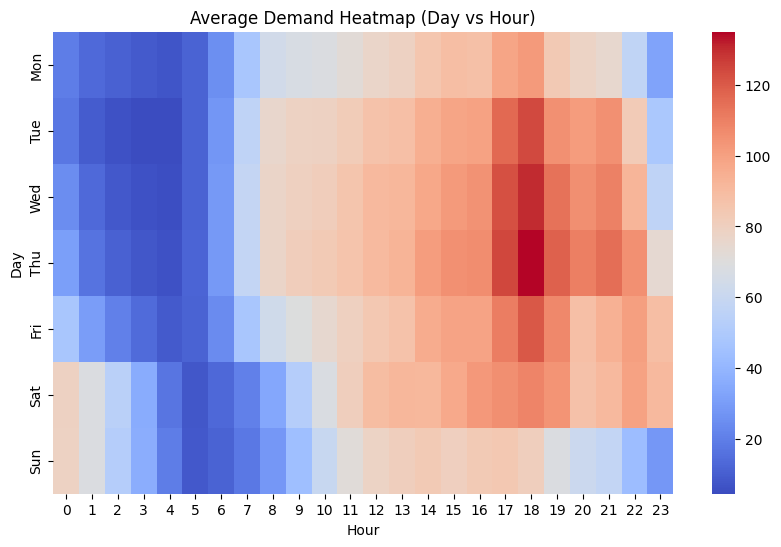

In [29]:
# plotting the average demand for days per hour

pivot_time = taxi_clean.pivot_table(
    values='trip_count',
    index='pickup_dow',
    columns='pickup_hour',
    aggfunc='mean'
)

# map numbers to days of the week
day_map = {
    0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu',
    4: 'Fri', 5: 'Sat', 6: 'Sun'
}

pivot_time.index = pivot_time.index.map(day_map)

pivot_time = pivot_time.reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

# plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(pivot_time.astype(float), cmap='coolwarm')

plt.title("Average Demand Heatmap (Day vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()

In [30]:
# compare top vs bottom zones
zone_mean = taxi_clean.groupby('PULocationID')['trip_count'].mean()

top_zone = zone_mean.sort_values(ascending=False).head(5)
bottom_zone = zone_mean.sort_values().head(5)

print("Top zones:\n", top_zone)
print("\nLowest zones:\n", bottom_zone)

Top zones:
 PULocationID
237    209.662972
161    200.793986
236    191.614756
162    152.594056
186     145.13825
Name: trip_count, dtype: Float64

Lowest zones:
 PULocationID
127    1.142857
243    1.451613
244    2.690117
202         3.0
152    3.019539
Name: trip_count, dtype: Float64


#### Possible Suggestions for Feature Engineering (Demand Prediction)

- cyclical encoding of hour (helps the model to recognise that late night is close to early morning)
- interaction between hour and weekend (could maybe see demand patterns at the same hour depending on wether it is a week day or weekend)
- demand change between the lag features (could see trends by measuring how demand is increasing or decreasing)
- calculating ratios for lag (could help see spikes in the data)
- calculating averages (could help capuring underlying trends and reduce noise a bit)


## Modelling : Predicting Demand

Training models for predicting demand.

In [34]:
demand_train = taxi_clean_train.copy()
demand_test = taxi_clean_test.copy()

In [ ]:
# define target variable
TARGET = 'trip_count'

# drop total_revenue due to correaltion close to 1 with target variable (leakage)
drop_cols = [
    'trip_count',
    'total_revenue',
    'avg_fare',
    'avg_duration_min'
]

X_train = demand_train.drop(columns=drop_cols)
y_train = demand_train[TARGET]

X_test = demand_test.drop(columns=drop_cols)
y_test = demand_test[TARGET]

In [ ]:
# identifying numeric columns
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

# preprocessing for linear regression and neural network
preprocess_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features)
])

# preprocessing for random forest
preprocess_tree = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), numeric_features)
])

# creating pipelines for all base models
models = {
    "Linear Regression": Pipeline([
        ("preprocess", preprocess_scaled),
        ("reg", LinearRegression())
    ]),
    
    "Random Forest": Pipeline([
        ("preprocess", preprocess_tree),
        ("reg", RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "Neural Network": Pipeline([
        ("preprocess", preprocess_scaled),
        ("reg", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            max_iter=500,
            random_state=42,
            early_stopping=True
        ))
    ])
}

# applying time series cross validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

# setting up scoring for evaluation
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "mape": "neg_mean_absolute_percentage_error",
    "r2": "r2"
}

results = []
# running models and appending results table
for name, pipe in models.items():
    cv_out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=tscv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    results.append({
        "Model": name,
        
        "MAE (CV)": -cv_out["test_mae"].mean(),
        "MAE Std": (-cv_out["test_mae"]).std(),
        
        "RMSE (CV)": -cv_out["test_rmse"].mean(),
        "RMSE Std": (-cv_out["test_rmse"]).std(),
        
        "MAPE (CV)": -cv_out["test_mape"].mean(),
        "MAPE Std": (-cv_out["test_mape"]).std(),
        
        "R2 (CV)": cv_out["test_r2"].mean(),
        "R2 Std": cv_out["test_r2"].std()
    })

results_df = pd.DataFrame(results).sort_values("RMSE (CV)", ascending=True)

results_df["MAPE (CV) %"] = results_df["MAPE (CV)"] * 100
results_df["MAPE Std %"] = results_df["MAPE Std"] * 100

display(results_df)


,Model,MAE (CV),MAE Std,RMSE (CV),RMSE Std,MAPE (CV),MAPE Std,R2 (CV),R2 Std,MAPE (CV) %,MAPE Std %
2,Neural Network,13.880381,0.986068,21.642314,1.902820,0.680153,0.225843,0.918152,0.038470,68.015302,22.584339
1,Random Forest,13.091498,2.254077,22.887559,2.894656,0.396790,0.059233,0.911585,0.037224,39.678993,5.923255
0,Linear Regression,15.059543,2.535298,24.769192,3.195817,0.601879,0.113171,0.900607,0.028657,60.187945,11.317099


## Final Model Selection for Demand Prediction : Random Forest

- achieved strong overall performance with RMSE close to NN
- produced the lowest MAE and MAPE which results in more consistent and reliable predictions
- shows greater stability across cross validation folds
- can also capture nonlinear patterns better than LR
- provides feature importance
- results are easier to interpret and explain than with NN

In [ ]:
# fine tune final model

# numeric columns
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

# preprocessing for random forest
preprocess_tree = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), numeric_features)
])

# define base random forest pipeline
rf_pipeline = Pipeline([
    ("preprocess", preprocess_tree),
    ("reg", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# CV for time series split with 5 splits
tscv_tune = TimeSeriesSplit(n_splits=5)

# specify parameter grid
param_grid = {
    "reg__n_estimators": [100, 200],
    "reg__max_depth": [8, 10, 12, None],
    "reg__min_samples_leaf": [1, 3, 5]
}

# do grid search
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=tscv_tune,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV RMSE:")
print(-grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
{'reg__max_depth': None, 'reg__min_samples_leaf': 5, 'reg__n_estimators': 200}

Best CV RMSE:
22.195944530889086


In [50]:
# select final model
final_model_name = "Fine Tuned Random Forest"
final_model = grid_search.best_estimator_

# fit on full training data
final_model.fit(X_train, y_train)

# predict on test data
y_pred = final_model.predict(X_test)

# evaluate on test set
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = root_mean_squared_error(y_test, y_pred)
test_mape = mean_absolute_percentage_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print("Final selected model:", final_model_name)
print(f"Test MAE:   {test_mae:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")
print(f"Test MAPE:  {test_mape:.4f}")
print(f"Test MAPE %: {test_mape * 100:.2f}%")
print(f"Test R2:    {test_r2:.4f}")

Final selected model: Fine Tuned Random Forest
Test MAE:   9.9162
Test RMSE:  17.2224
Test MAPE:  0.3509
Test MAPE %: 35.09%
Test R2:    0.9508


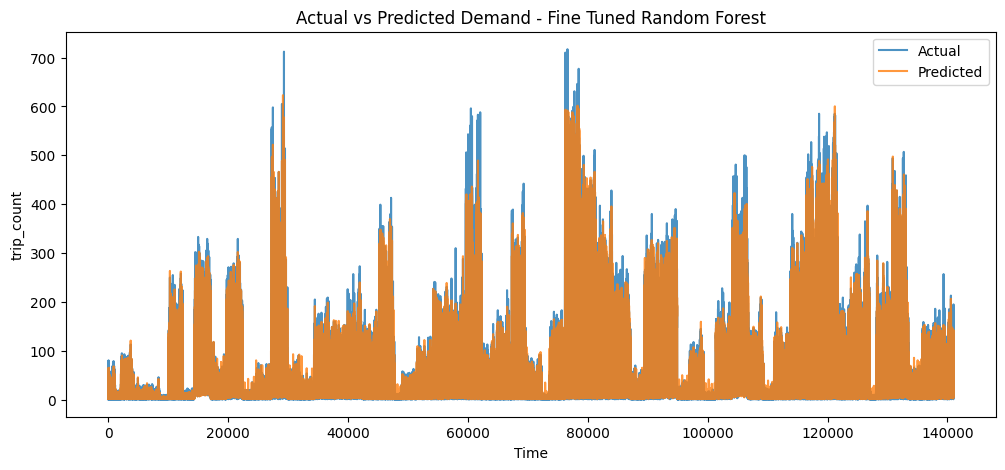

In [ ]:
# plot actual vs predicted demand for the fine tuned model
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual", alpha=0.8)
plt.plot(y_pred, label="Predicted", alpha=0.8)
plt.title(f"Actual vs Predicted Demand - {final_model_name}")
plt.xlabel("Time")
plt.ylabel("trip_count")
plt.legend()
plt.show()

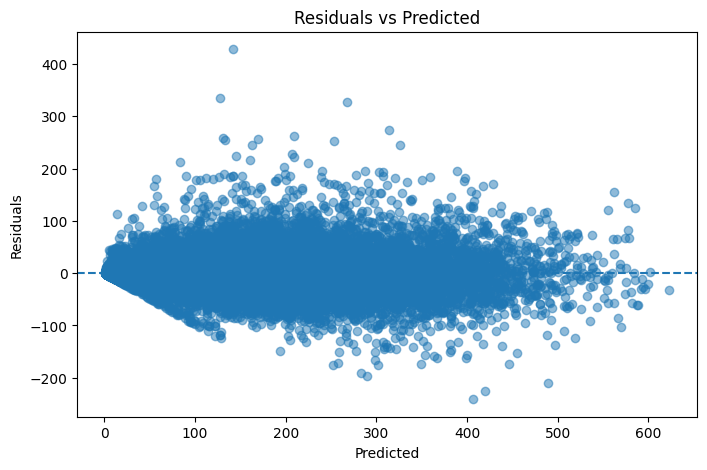

In [ ]:
# residual plot to show bias and variance

residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

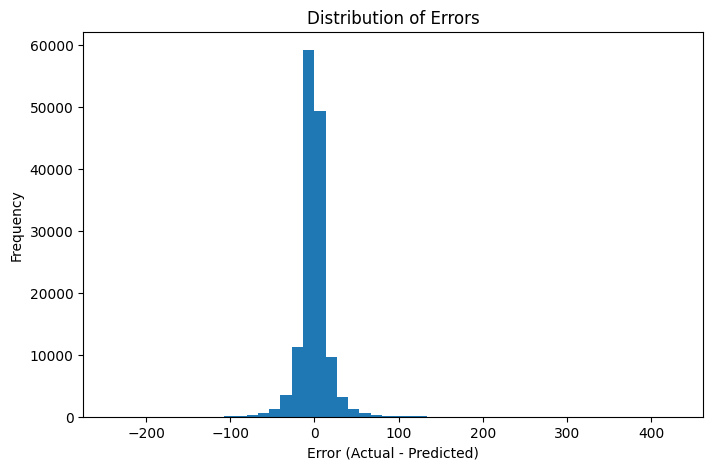

In [ ]:
# plot error distribution
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=50)
plt.title("Distribution of Errors")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

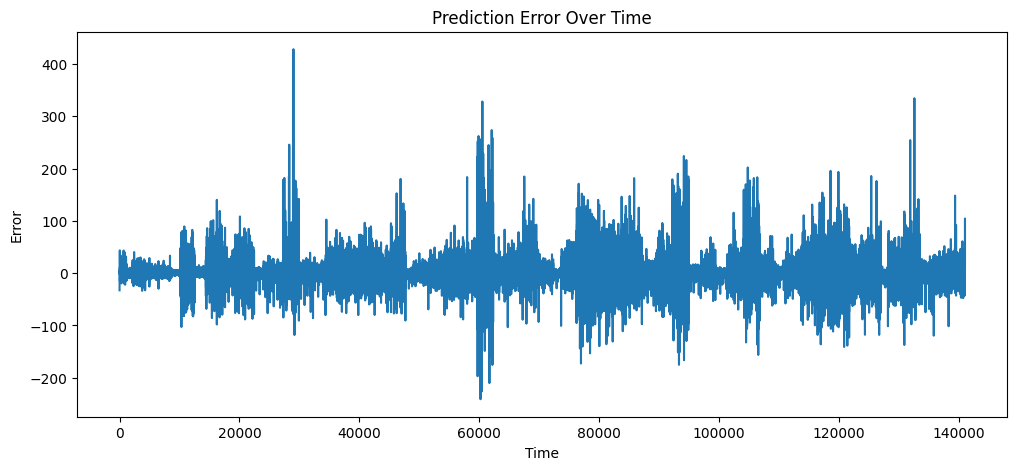

In [ ]:
# plot error over time
plt.figure(figsize=(12,5))
plt.plot(residuals.values)
plt.title("Prediction Error Over Time")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

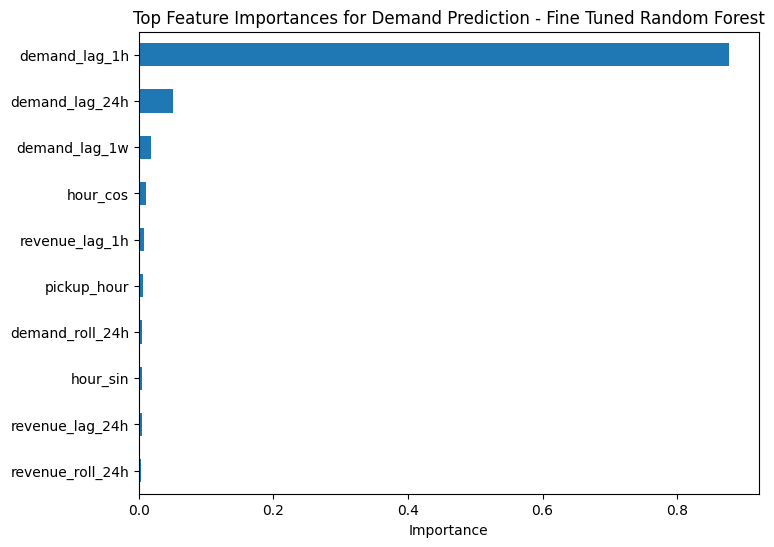

In [58]:
# plot feature importance in fine tuned model
feat_imp = pd.Series(
    final_model.named_steps["reg"].feature_importances_,
    index=numeric_features
).sort_values()

plt.figure(figsize=(8, 6))
feat_imp.tail(10).plot(kind="barh")
plt.title("Top Feature Importances for Demand Prediction - Fine Tuned Random Forest")
plt.xlabel("Importance")
plt.show()